# 07 · What-If Business Simulator
**SaaS Churn Intelligence** — Policy Simulation & Scenario Analysis

---

> **The key question this notebook answers:**
> *"If we change X for Y% of customers, how much churn do we prevent and what's the ROI?"*

This notebook lets you simulate **business policy decisions** against the trained GBM model
before spending a single dollar — turning the ML model into a **strategic planning tool**.

| Section | What you'll see |
|---------|----------------|
| 1. Setup | Load model, reconstruct full dataset |
| 2. Baseline | Current churn profile & revenue at risk |
| 3. Policy Simulator | 5 pre-built business scenarios |
| 4. Policy Comparison | Side-by-side ROI chart |
| 5. Sensitivity Analysis | How % of customers converted affects revenue |
| 6. Custom Simulator | Build your own policy interactively |
| 7. Optimal Budget Allocation | How to distribute $100K retention budget |
| 8. Executive Summary | One-page board-ready output |


## 1 · Setup

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
import os
import pathlib
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
os.makedirs("../outputs", exist_ok=True)

# ── Dark theme ────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor":  "#0f1117",
    "axes.edgecolor":   "#2d3a4a", "axes.labelcolor": "#c9d1d9",
    "xtick.color":      "#8b949e", "ytick.color":     "#8b949e",
    "text.color":       "#e6edf3", "grid.color":      "#21262d",
    "grid.linestyle":   "--",      "grid.alpha":      0.4,
    "font.family":      "monospace","axes.titlesize":  12,
    "figure.dpi":       120,
})
GREEN  = "#00e5a0"; RED   = "#ff4d6d"
AMBER  = "#ffbe0b"; PURPLE= "#7c6fff"
BLUE   = "#58a6ff"; MUTED = "#8b949e"
COLORS = [GREEN, PURPLE, AMBER, BLUE, RED]

print("✅ Setup complete")


✅ Setup complete


## 2 · Load Model & Baseline

In [19]:
# ── Auto-detect paths ────────────────────────────────────────
def find_file(name):
    start = pathlib.Path.cwd()
    for base in [start] + list(start.parents)[:4]:
        for pattern in [base/name,
                        base/"data"/"processed"/name,
                        base/"data"/name,
                        base/"models"/name]:
            if pattern.exists(): return pattern
    raise FileNotFoundError(f"Cannot find '{name}'. Set path manually.")

DATA_PATH  = find_file("crm_churn_ml_ready.csv")
MODEL_PATH = find_file("best_churn_model.pkl")
META_PATH  = find_file("meta.pkl")

model = joblib.load(MODEL_PATH)
meta  = joblib.load(META_PATH)
CAT, NUM = meta["cat_cols"], meta["num_cols"]
THRESHOLD = meta["opt_threshold"]

# ── Load full dataset ─────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["customer_id","state"], errors="ignore")
for c in CAT: df[c] = df[c].fillna("Unknown")

# ── Feature Engineering (must match NB04 exactly) ────────────
NUM_BASE = ["number_of_referrals","total_extra_data_charges","total_revenue",
            "total_charges","tenure_in_months","age","monthly_charge",
            "total_refunds","total_long_distance_charges"]
for c in NUM_BASE:
    if c in df.columns: df[c] = df[c].fillna(df[c].median())

if "is_m2m" in NUM:   # v3 model with engineered features
    df["is_m2m"]        = (df["contract"] == "Month-to-Month").astype(float)
    df["is_fiber"]      = (df["internet_type"] == "Fiber Optic").astype(float)
    df["has_security"]  = (df["online_security"] == "Yes").astype(float)
    df["addon_count"]   = sum((df[c] == "Yes").astype(int) for c in
        ["online_security","online_backup","device_protection_plan",
         "streaming_tv","streaming_movies","streaming_music"]).astype(float)
    df["high_m2m"]      = (df["is_m2m"] * (df["monthly_charge"] > 70)).astype(float)
    df["new_fiber"]     = (df["is_fiber"] * (df["tenure_in_months"] < 12)).astype(float)
    df["zero_ref_m2m"]  = (df["is_m2m"] * (df["number_of_referrals"] == 0)).astype(float)
    df["m2m_fiber"]     = (df["is_m2m"] * df["is_fiber"]).astype(float)
    df["m2m_no_sec"]    = (df["is_m2m"] * (df["has_security"] == 0)).astype(float)
    df["low_addon_m2m"] = (df["is_m2m"] * (df["addon_count"] <= 1)).astype(float)
    df["rev_tenure"]    = (df["total_revenue"] / (df["tenure_in_months"] + 1)).clip(0, 500)
    print("\u2705 11 engineered features added (v3 model)")

# ── Build X/y AFTER engineering ──────────────────────────────
for c in NUM:
    if c in df.columns: df[c] = df[c].fillna(df[c].median())
X = df.drop("churn", axis=1); y = df["churn"]

# ── Reconstruct test split ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ── Baseline predictions ──────────────────────────────────────
ORIG_PROB  = model.predict_proba(X_test)[:, 1]
MONTHLY    = X_test["monthly_charge"].values
AVG_MONTHLY = MONTHLY.mean()

# Revenue metrics
REV_PER_SAVE   = AVG_MONTHLY * 18       # 18-month LTV
TOTAL_REV_RISK = (ORIG_PROB * MONTHLY * 18).sum()
HIGH_RISK      = (ORIG_PROB >= 0.60).sum()
MEDIUM_RISK    = ((ORIG_PROB >= 0.30) & (ORIG_PROB < 0.60)).sum()
LOW_RISK       = (ORIG_PROB < 0.30).sum()

print(f"Dataset        : {len(X_test):,} test customers")
print(f"Churn rate     : {y_test.mean()*100:.1f}%")
print(f"Avg monthly    : ${AVG_MONTHLY:.2f}")
print(f"Rev at risk    : ${TOTAL_REV_RISK:,.0f}")
print()
print(f"Risk breakdown :")
print(f"  🔴 HIGH   : {HIGH_RISK:,}  ({HIGH_RISK/len(X_test)*100:.1f}%)")
print(f"  🟡 MEDIUM : {MEDIUM_RISK:,}  ({MEDIUM_RISK/len(X_test)*100:.1f}%)")
print(f"  🟢 LOW    : {LOW_RISK:,}  ({LOW_RISK/len(X_test)*100:.1f}%)")


✅ 11 engineered features added (v3 model)
Dataset        : 2,693 test customers
Churn rate     : 26.7%
Avg monthly    : $64.40
Rev at risk    : $909,686

Risk breakdown :
  🔴 HIGH   : 555  (20.6%)
  🟡 MEDIUM : 229  (8.5%)
  🟢 LOW    : 1,909  (70.9%)


## 3 · Baseline Dashboard

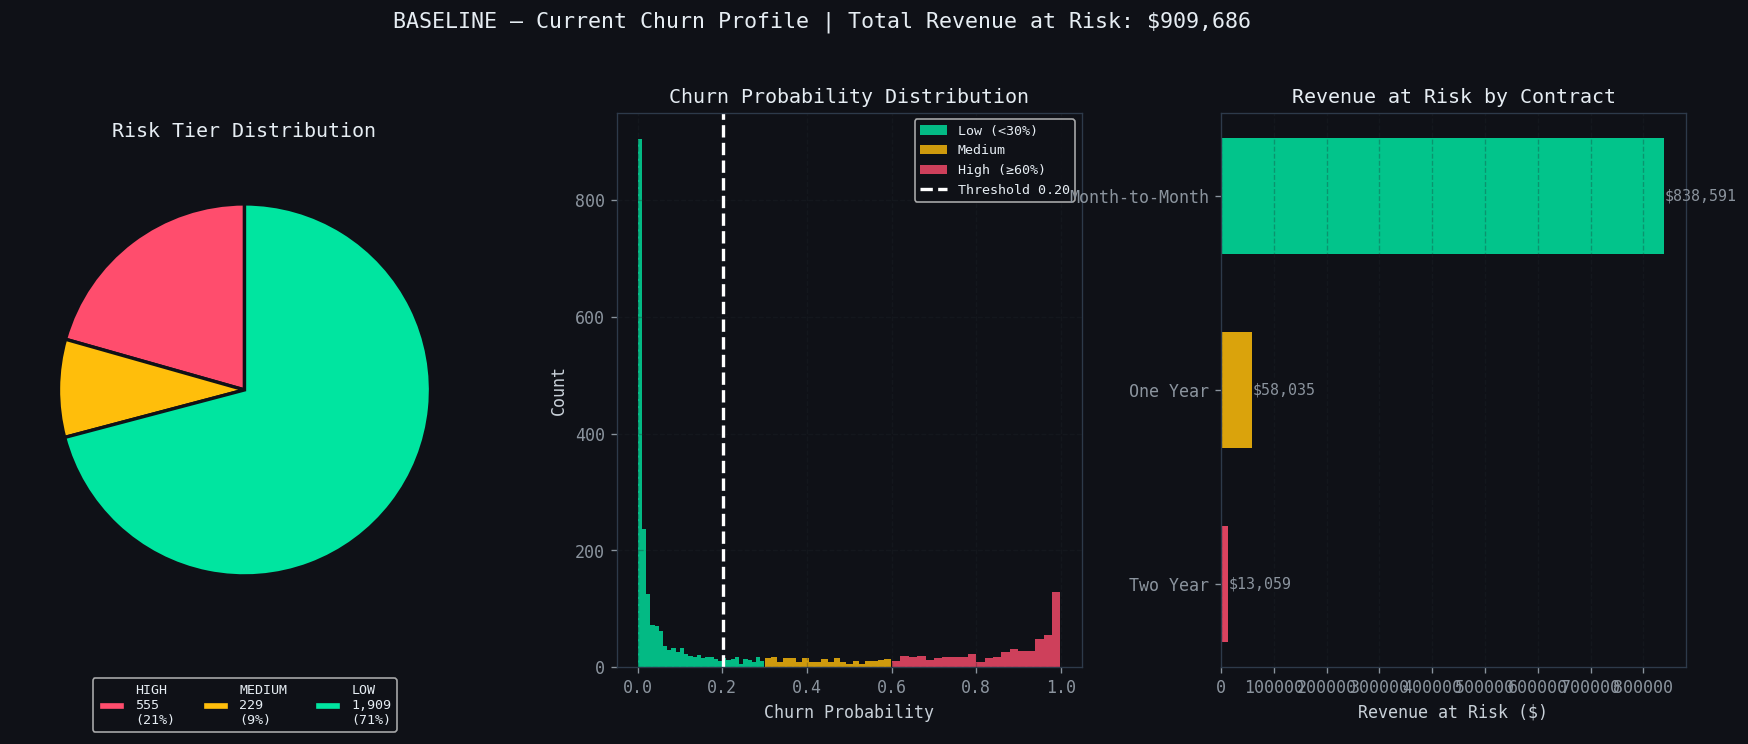

Total revenue at risk: $909,686


In [20]:
fig = plt.figure(figsize=(18, 6))
fig.patch.set_facecolor("#0f1117")
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.3)

# Chart 1: Risk tier pie
ax1 = fig.add_subplot(gs[0])
sizes  = [HIGH_RISK, MEDIUM_RISK, LOW_RISK]
labels = [f"HIGH\n{HIGH_RISK:,}\n({HIGH_RISK/len(X_test)*100:.0f}%)",
          f"MEDIUM\n{MEDIUM_RISK:,}\n({MEDIUM_RISK/len(X_test)*100:.0f}%)",
          f"LOW\n{LOW_RISK:,}\n({LOW_RISK/len(X_test)*100:.0f}%)"]
wedges, texts = ax1.pie(sizes, colors=[RED, AMBER, GREEN],
                         startangle=90, wedgeprops=dict(edgecolor="#0f1117", linewidth=2))
ax1.legend(wedges, labels, loc="lower center", bbox_to_anchor=(0.5,-0.25),
           fontsize=8, ncol=3)
ax1.set_title("Risk Tier Distribution", pad=12)

# Chart 2: Probability distribution
ax2 = fig.add_subplot(gs[1])
ax2.hist(ORIG_PROB[ORIG_PROB < 0.30],  bins=30, color=GREEN,  alpha=0.8, label="Low (<30%)")
ax2.hist(ORIG_PROB[(ORIG_PROB>=0.30) & (ORIG_PROB<0.60)], bins=20, color=AMBER, alpha=0.8, label="Medium")
ax2.hist(ORIG_PROB[ORIG_PROB >= 0.60], bins=20, color=RED,    alpha=0.8, label="High (≥60%)")
ax2.axvline(THRESHOLD, color="white", lw=2, linestyle="--", label=f"Threshold {THRESHOLD:.2f}")
ax2.set_xlabel("Churn Probability"); ax2.set_ylabel("Count")
ax2.set_title("Churn Probability Distribution")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# Chart 3: Revenue at risk by contract
ax3 = fig.add_subplot(gs[2])
rev_by_contract = X_test.copy()
rev_by_contract["prob"]    = ORIG_PROB
rev_by_contract["rev_risk"]= ORIG_PROB * MONTHLY * 18
grp = rev_by_contract.groupby("contract")["rev_risk"].sum().sort_values(ascending=True)
bars = ax3.barh(grp.index, grp.values, color=[RED, AMBER, GREEN], alpha=0.85, height=0.6)
for bar in bars:
    w = bar.get_width()
    ax3.text(w + 1000, bar.get_y()+bar.get_height()/2,
             f"${w:,.0f}", va="center", fontsize=9, color=MUTED)
ax3.set_xlabel("Revenue at Risk ($)")
ax3.set_title("Revenue at Risk by Contract")
ax3.grid(True, axis="x", alpha=0.3)

plt.suptitle(f"BASELINE — Current Churn Profile | Total Revenue at Risk: ${TOTAL_REV_RISK:,.0f}",
             fontsize=13, y=1.02, color="#e6edf3")
plt.savefig("../outputs/07_baseline_dashboard.png", bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"Total revenue at risk: ${TOTAL_REV_RISK:,.0f}")


## 4 · Policy Simulator

Each policy represents a **real business decision** a retention team could make.
The model scores every customer under the new policy and measures the delta.

> **How it works:** We modify the feature values for the affected customers,
> re-run the GBM model, and measure the reduction in predicted churn probability × revenue.


In [21]:
def simulate_policy(X_base, transform_fn, cost_per_customer=50,
                    affected_mask=None, label="Policy"):
    """
    Run a what-if simulation on X_base.
    
    Parameters
    ----------
    X_base        : original test DataFrame
    transform_fn  : function(X_copy) → modifies X in place
    cost_per_customer : intervention cost per affected customer
    affected_mask : boolean mask of targeted customers
    label         : policy name for display
    
    Returns
    -------
    dict with revenue_saved, cost, net_roi, sim_prob, churn_reduction
    """
    X_sim     = X_base.copy()
    transform_fn(X_sim)
    
    sim_prob  = model.predict_proba(X_sim)[:, 1]
    churn_red = (ORIG_PROB - sim_prob).clip(min=0)
    rev_saved = (churn_red * X_base["monthly_charge"] * 18).sum()
    
    n_affected = affected_mask.sum() if affected_mask is not None else len(X_base)
    total_cost = n_affected * cost_per_customer
    net_roi    = rev_saved - total_cost
    
    return {
        "label":           label,
        "n_affected":      int(n_affected),
        "avg_prob_before": float(ORIG_PROB[affected_mask].mean() if affected_mask is not None else ORIG_PROB.mean()),
        "avg_prob_after":  float(sim_prob[affected_mask].mean()  if affected_mask is not None else sim_prob.mean()),
        "revenue_saved":   float(rev_saved),
        "cost":            float(total_cost),
        "net_roi":         float(net_roi),
        "roi_ratio":       float(rev_saved / total_cost) if total_cost > 0 else 0,
        "sim_prob":        sim_prob,
    }

# ─────────────────────────────────────────────────────
# POLICY 1: Convert 30% of M2M customers to One Year
# ─────────────────────────────────────────────────────
rng = np.random.RandomState(42)
m2m_mask = X_test["contract"] == "Month-to-Month"
conv_mask = m2m_mask & (rng.rand(len(X_test)) < 0.30)

def policy1(X):
    X.loc[conv_mask, "contract"] = "One Year"

P1 = simulate_policy(X_test, policy1,
                     cost_per_customer=50,
                     affected_mask=conv_mask,
                     label="P1: 30% M2M → One Year")

# ─────────────────────────────────────────────────────
# POLICY 2: $10/month discount for HIGH RISK customers
# ─────────────────────────────────────────────────────
high_mask = ORIG_PROB >= 0.60

def policy2(X):
    X.loc[high_mask, "monthly_charge"] = (X.loc[high_mask, "monthly_charge"] - 10).clip(lower=20)

P2 = simulate_policy(X_test, policy2,
                     cost_per_customer=180,   # $10 × 18 months foregone revenue
                     affected_mask=high_mask,
                     label="P2: $10 Discount → HIGH RISK")

# ─────────────────────────────────────────────────────
# POLICY 3: Add Online Security to customers without it
# ─────────────────────────────────────────────────────
no_sec_mask = X_test["online_security"].isin(["No", "0"])

def policy3(X):
    X.loc[no_sec_mask, "online_security"] = "Yes"

P3 = simulate_policy(X_test, policy3,
                     cost_per_customer=60,   # $5/mo × 12mo promotional
                     affected_mask=no_sec_mask,
                     label="P3: Free Security Add-on")

# ─────────────────────────────────────────────────────
# POLICY 4: Convert ALL M2M → One Year (aggressive)
# ─────────────────────────────────────────────────────
def policy4(X):
    X.loc[m2m_mask, "contract"] = "One Year"

P4 = simulate_policy(X_test, policy4,
                     cost_per_customer=100,   # incentive to switch
                     affected_mask=m2m_mask,
                     label="P4: ALL M2M → One Year")

# ─────────────────────────────────────────────────────
# POLICY 5: Combined — 30% M2M upgrade + security add-on
# ─────────────────────────────────────────────────────
combo_mask = conv_mask | no_sec_mask

def policy5(X):
    X.loc[conv_mask,    "contract"]       = "One Year"
    X.loc[no_sec_mask,  "online_security"]= "Yes"

P5 = simulate_policy(X_test, policy5,
                     cost_per_customer=55,
                     affected_mask=combo_mask,
                     label="P5: M2M Upgrade + Security")

POLICIES = [P1, P2, P3, P4, P5]

# ── Print summary table ───────────────────────────────────────
print(f"{'Policy':<35} {'Affected':>9} {'Rev Saved':>12} {'Cost':>11} {'Net ROI':>12} {'ROI Ratio':>10}")
print("─" * 91)
for p in POLICIES:
    print(f"{p['label']:<35} {p['n_affected']:>9,} "
          f"${p['revenue_saved']:>11,.0f} "
          f"${p['cost']:>10,.0f} "
          f"${p['net_roi']:>11,.0f} "
          f"{p['roi_ratio']:>9.1f}x")


Policy                               Affected    Rev Saved        Cost      Net ROI  ROI Ratio
───────────────────────────────────────────────────────────────────────────────────────────
P1: 30% M2M → One Year                    437 $     33,285 $    21,850 $     11,435       1.5x
P2: $10 Discount → HIGH RISK              555 $     78,709 $    99,900 $    -21,191       0.8x
P3: Free Security Add-on                1,653 $     38,980 $    99,180 $    -60,200       0.4x
P4: ALL M2M → One Year                  1,385 $    113,445 $   138,500 $    -25,055       0.8x
P5: M2M Upgrade + Security              1,762 $     73,237 $    96,910 $    -23,673       0.8x


## 5 · Policy Comparison Chart

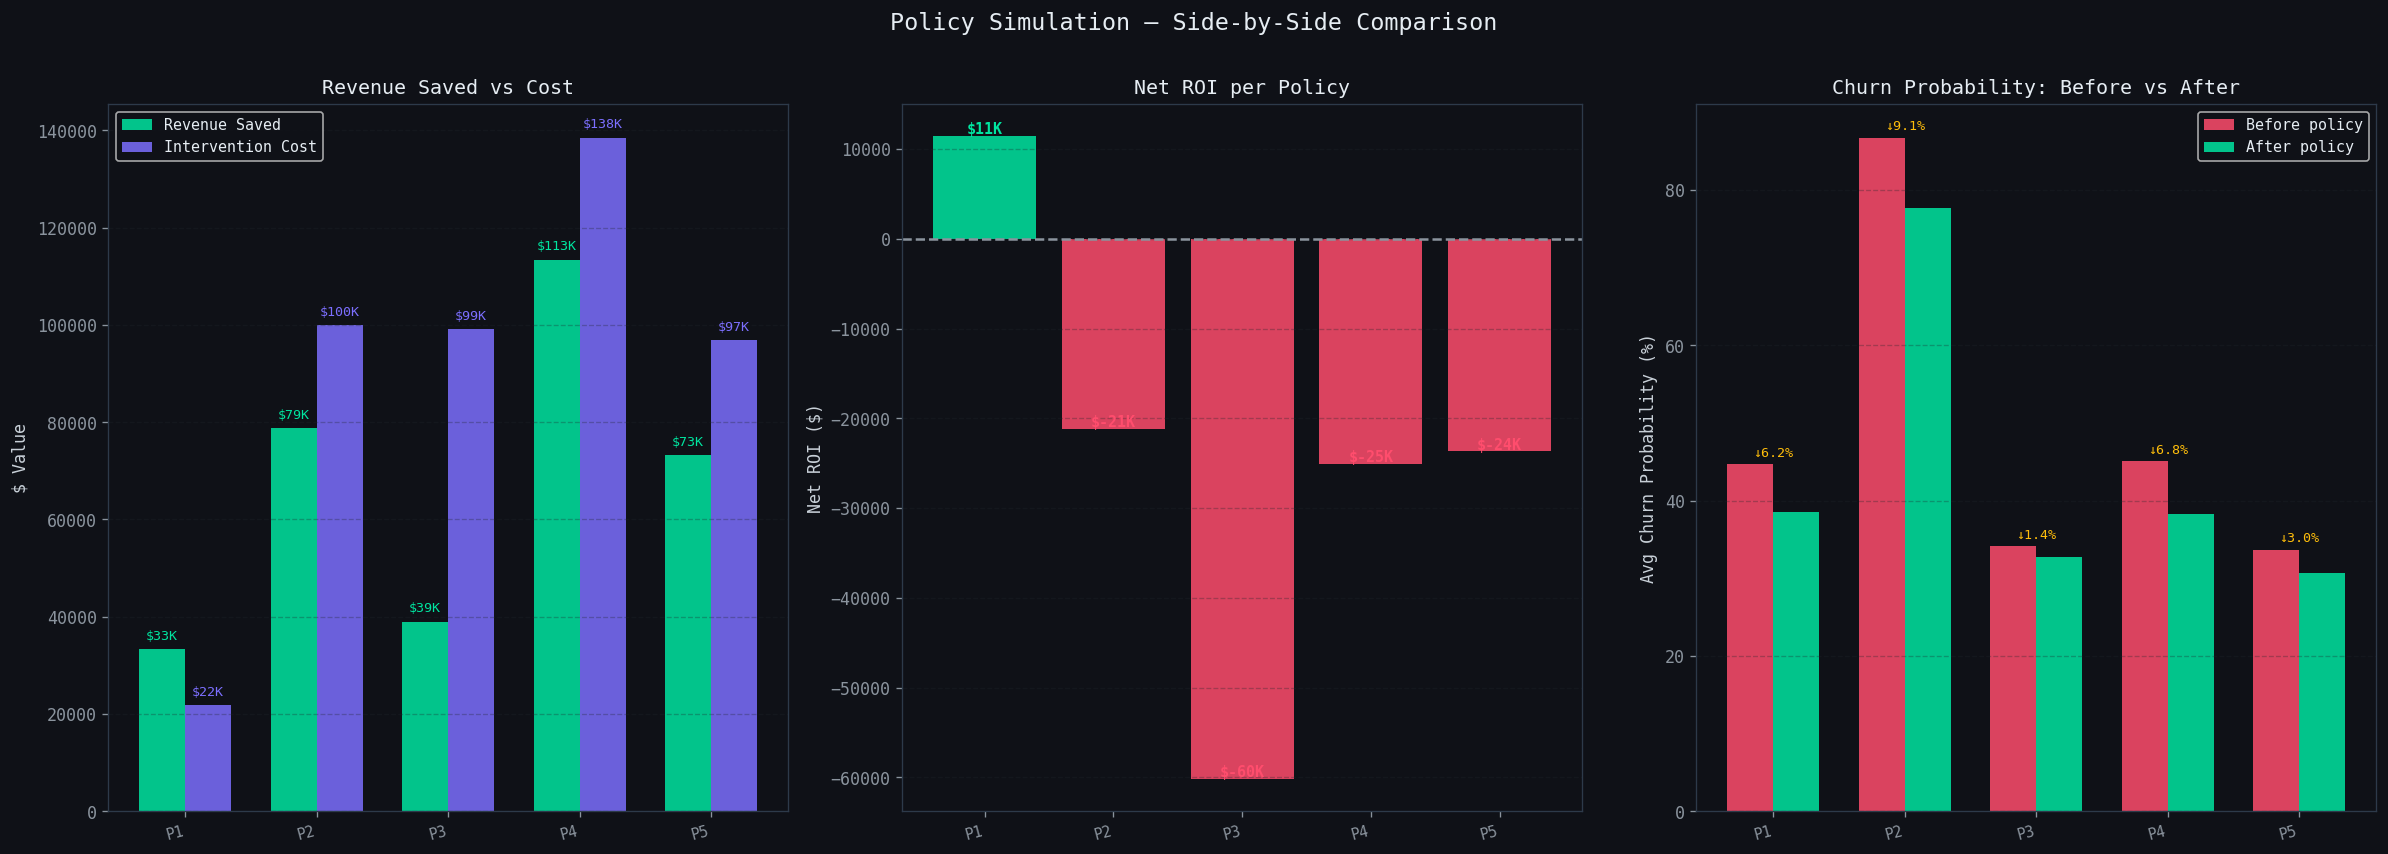


🏆 Best policy by Net ROI: P1: 30% M2M → One Year
   Net ROI: $11,435  |  ROI ratio: 1.5x


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor("#0f1117")

labels    = [p["label"].split(":")[0] for p in POLICIES]
rev_saved = [p["revenue_saved"] for p in POLICIES]
costs     = [p["cost"]          for p in POLICIES]
net_rois  = [p["net_roi"]       for p in POLICIES]
roi_ratio = [p["roi_ratio"]     for p in POLICIES]

bar_colors = [GREEN if n > 0 else RED for n in net_rois]

# Chart 1: Revenue Saved vs Cost
ax = axes[0]
x = np.arange(len(POLICIES))
w = 0.35
ax.bar(x - w/2, rev_saved, w, color=GREEN,  alpha=0.85, label="Revenue Saved")
ax.bar(x + w/2, costs,     w, color=PURPLE, alpha=0.85, label="Intervention Cost")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("$ Value"); ax.set_title("Revenue Saved vs Cost")
ax.legend(fontsize=9); ax.grid(True, axis="y", alpha=0.3)
for i, (r, c) in enumerate(zip(rev_saved, costs)):
    ax.text(i-w/2, r+2000, f"${r/1000:.0f}K", ha="center", fontsize=8, color=GREEN)
    ax.text(i+w/2, c+2000, f"${c/1000:.0f}K", ha="center", fontsize=8, color=PURPLE)

# Chart 2: Net ROI
ax = axes[1]
bars = ax.bar(labels, net_rois, color=bar_colors, alpha=0.85, edgecolor="none")
ax.axhline(0, color=MUTED, lw=1.5, linestyle="--")
ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Net ROI ($)"); ax.set_title("Net ROI per Policy")
ax.grid(True, axis="y", alpha=0.3)
for bar, val in zip(bars, net_rois):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (max(net_rois)*0.02),
            f"${val/1000:.0f}K",
            ha="center", fontsize=9, fontweight="bold",
            color=GREEN if val > 0 else RED)

# Chart 3: Probability before vs after per policy
ax = axes[2]
before = [p["avg_prob_before"] * 100 for p in POLICIES]
after  = [p["avg_prob_after"]  * 100 for p in POLICIES]
x = np.arange(len(POLICIES))
ax.bar(x - w/2, before, w, color=RED,   alpha=0.85, label="Before policy")
ax.bar(x + w/2, after,  w, color=GREEN, alpha=0.85, label="After policy")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Avg Churn Probability (%)"); ax.set_title("Churn Probability: Before vs After")
ax.legend(fontsize=9); ax.grid(True, axis="y", alpha=0.3)
for i, (b, a) in enumerate(zip(before, after)):
    ax.text(i, max(b,a)+1, f"↓{b-a:.1f}%", ha="center", fontsize=8, color=AMBER)

plt.suptitle("Policy Simulation — Side-by-Side Comparison",
             fontsize=14, y=1.01, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/07_policy_comparison.png", bbox_inches="tight", facecolor="#0f1117")
plt.show()

best = max(POLICIES, key=lambda p: p["net_roi"])
print(f"\n🏆 Best policy by Net ROI: {best['label']}")
print(f"   Net ROI: ${best['net_roi']:,.0f}  |  ROI ratio: {best['roi_ratio']:.1f}x")


## 6 · Sensitivity Analysis — How Conversion Rate Affects ROI

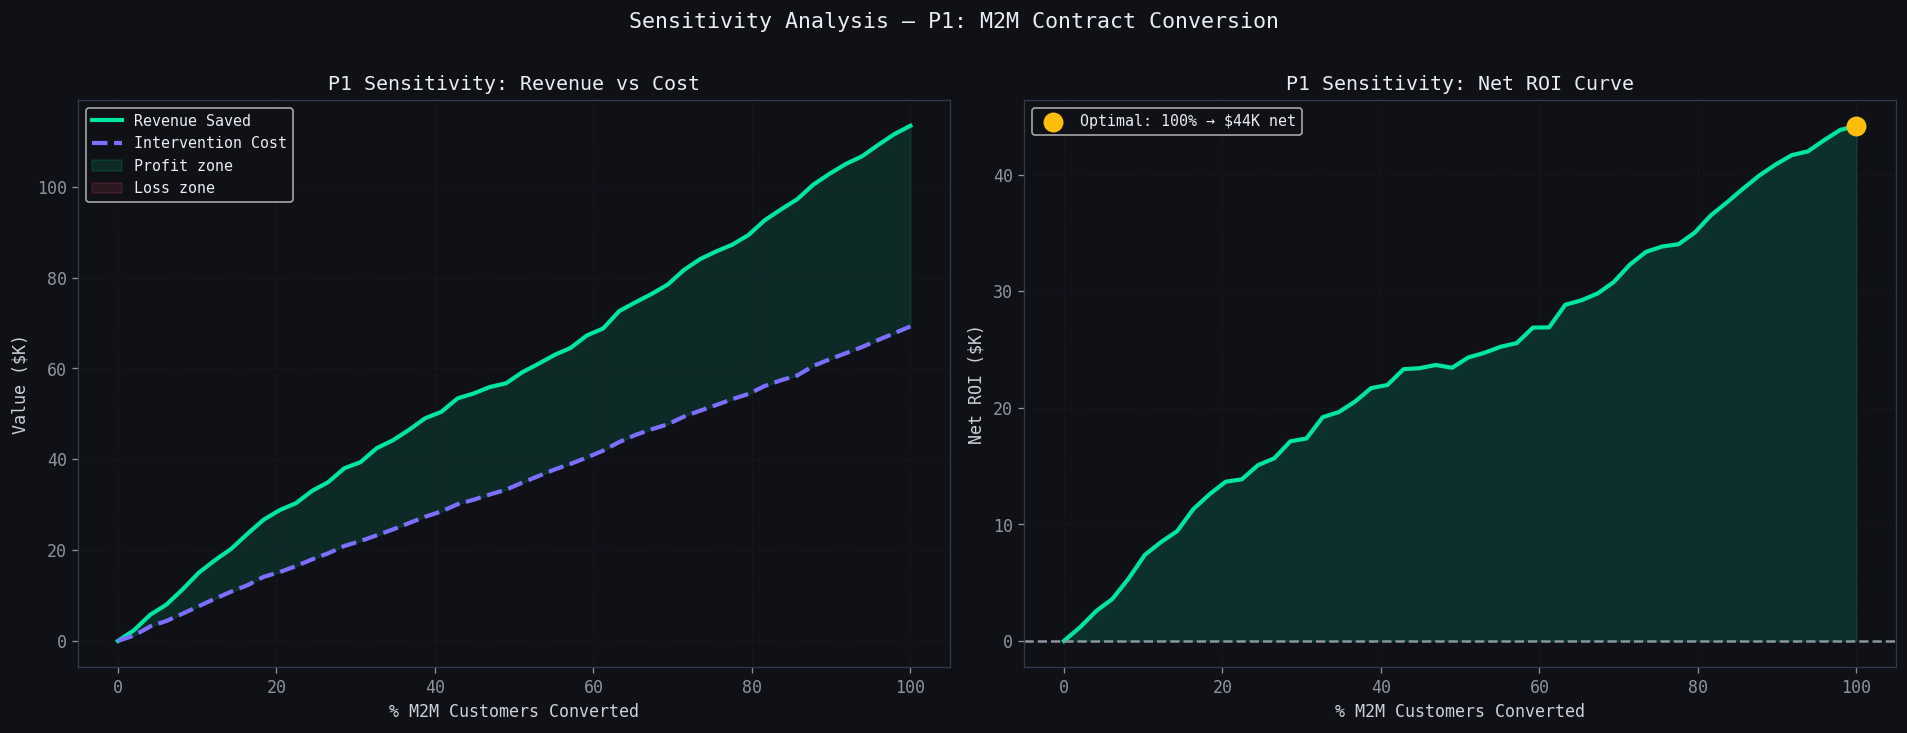

Never breaks even
Optimal conversion rate    : 100%
Max net ROI                : $44,195


In [23]:
# For Policy 1 (M2M → One Year), sweep conversion rate 0% → 100%
conversion_rates = np.linspace(0, 1.0, 50)
results = []

m2m_customers = X_test[X_test["contract"] == "Month-to-Month"]
m2m_idx       = m2m_customers.index

for rate in conversion_rates:
    rng_s = np.random.RandomState(42)
    conv  = rng_s.rand(len(m2m_idx)) < rate
    conv_idx = m2m_idx[conv]
    
    X_s = X_test.copy()
    X_s.loc[conv_idx, "contract"] = "One Year"
    
    sim_prob  = model.predict_proba(X_s)[:, 1]
    rev_saved = ((ORIG_PROB - sim_prob).clip(0) * MONTHLY * 18).sum()
    cost      = len(conv_idx) * 50
    net_roi   = rev_saved - cost
    
    results.append({
        "rate":      rate * 100,
        "converted": len(conv_idx),
        "rev_saved": rev_saved,
        "cost":      cost,
        "net_roi":   net_roi,
    })

sens_df = pd.DataFrame(results)
break_even = sens_df[sens_df["net_roi"] >= 0].iloc[0]["rate"] if (sens_df["net_roi"] >= 0).any() else None
optimal    = sens_df.loc[sens_df["net_roi"].idxmax()]

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0f1117")

ax = axes[0]
ax.plot(sens_df["rate"], sens_df["rev_saved"]/1000, color=GREEN,  lw=2.5, label="Revenue Saved")
ax.plot(sens_df["rate"], sens_df["cost"]/1000,      color=PURPLE, lw=2.5, linestyle="--", label="Intervention Cost")
ax.fill_between(sens_df["rate"],
                sens_df["rev_saved"]/1000,
                sens_df["cost"]/1000,
                where=sens_df["net_roi"]>=0,
                alpha=0.12, color=GREEN, label="Profit zone")
ax.fill_between(sens_df["rate"],
                sens_df["rev_saved"]/1000,
                sens_df["cost"]/1000,
                where=sens_df["net_roi"]<0,
                alpha=0.12, color=RED, label="Loss zone")
if break_even:
    ax.axvline(break_even, color=AMBER, lw=2, linestyle=":",
               label=f"Break-even @ {break_even:.1f}%")
ax.set_xlabel("% M2M Customers Converted")
ax.set_ylabel("Value ($K)"); ax.set_title("P1 Sensitivity: Revenue vs Cost")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(sens_df["rate"], sens_df["net_roi"]/1000,
        color=GREEN, lw=2.5)
ax.fill_between(sens_df["rate"], sens_df["net_roi"]/1000, 0,
                where=sens_df["net_roi"]>=0, alpha=0.15, color=GREEN)
ax.fill_between(sens_df["rate"], sens_df["net_roi"]/1000, 0,
                where=sens_df["net_roi"]<0,  alpha=0.15, color=RED)
ax.axhline(0, color=MUTED, lw=1.5, linestyle="--")
ax.scatter(optimal["rate"], optimal["net_roi"]/1000,
           color=AMBER, s=120, zorder=5,
           label=f"Optimal: {optimal['rate']:.0f}% → ${optimal['net_roi']/1000:.0f}K net")
if break_even:
    ax.axvline(break_even, color=AMBER, lw=1.5, linestyle=":",
               label=f"Break-even @ {break_even:.1f}%")
ax.set_xlabel("% M2M Customers Converted")
ax.set_ylabel("Net ROI ($K)"); ax.set_title("P1 Sensitivity: Net ROI Curve")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle("Sensitivity Analysis — P1: M2M Contract Conversion",
             fontsize=13, y=1.01, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/07_sensitivity_analysis.png", bbox_inches="tight", facecolor="#0f1117")
plt.show()

print(f"Break-even conversion rate : {break_even:.1f}%" if break_even else "Never breaks even")
print(f"Optimal conversion rate    : {optimal['rate']:.0f}%")
print(f"Max net ROI                : ${optimal['net_roi']:,.0f}")


## 7 · Custom What-If Simulator

In [24]:
def what_if(
    contract_upgrade_pct  = 0.0,   # % of M2M to upgrade to One Year (0-1)
    discount_pct          = 0.0,   # % discount on monthly charge for HIGH RISK (0-1)
    add_security          = False, # Give free security add-on to all without it
    add_backup            = False, # Give free online backup to all without it
    target_tier           = "all", # "high", "medium", "low", "all"
    cost_per_action       = 50,    # $ cost per customer touched
    label                 = "Custom Policy"
):
    """
    Build any custom retention policy and see its predicted ROI.
    
    Examples
    --------
    # Convert 50% of M2M + give 20% discount to high-risk customers
    what_if(contract_upgrade_pct=0.5, discount_pct=0.20)
    
    # Add security to everyone for free
    what_if(add_security=True, cost_per_action=60)
    """
    X_sim = X_test.copy()
    affected = np.zeros(len(X_test), dtype=bool)
    
    # Tier filter
    if target_tier == "high":
        tier_mask = ORIG_PROB >= 0.60
    elif target_tier == "medium":
        tier_mask = (ORIG_PROB >= 0.30) & (ORIG_PROB < 0.60)
    elif target_tier == "low":
        tier_mask = ORIG_PROB < 0.30
    else:
        tier_mask = np.ones(len(X_test), dtype=bool)
    
    # Contract upgrade
    if contract_upgrade_pct > 0:
        rng_c  = np.random.RandomState(42)
        m2m    = (X_sim["contract"] == "Month-to-Month") & tier_mask
        to_up  = m2m & (rng_c.rand(len(X_sim)) < contract_upgrade_pct)
        X_sim.loc[to_up, "contract"] = "One Year"
        affected |= to_up
    
    # Monthly discount
    if discount_pct > 0:
        disc_mask = tier_mask.copy()
        X_sim.loc[disc_mask, "monthly_charge"] *= (1 - discount_pct)
        affected |= disc_mask
    
    # Add-ons
    if add_security:
        sec_mask = X_sim["online_security"].isin(["No","0"]) & tier_mask
        X_sim.loc[sec_mask, "online_security"] = "Yes"
        affected |= sec_mask
    
    if add_backup:
        bkp_mask = X_sim["online_backup"].isin(["No","0"]) & tier_mask
        X_sim.loc[bkp_mask, "online_backup"] = "Yes"
        affected |= bkp_mask
    
    sim_prob  = model.predict_proba(X_sim)[:, 1]
    churn_red = (ORIG_PROB - sim_prob).clip(0)
    rev_saved = (churn_red * X_test["monthly_charge"] * 18).sum()
    cost      = affected.sum() * cost_per_action
    net_roi   = rev_saved - cost
    
    print(f"{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Customers targeted : {affected.sum():,}")
    print(f"  Avg churn before   : {ORIG_PROB[affected].mean()*100:.1f}%")
    print(f"  Avg churn after    : {sim_prob[affected].mean()*100:.1f}%")
    print(f"  Revenue saved      : ${rev_saved:,.0f}")
    print(f"  Intervention cost  : ${cost:,.0f}")
    print(f"  Net ROI            : ${net_roi:,.0f}  ({rev_saved/cost:.1f}x)" if cost>0 else f"  Net ROI: ${net_roi:,.0f}")
    print()
    return {"net_roi": net_roi, "rev_saved": rev_saved, "cost": cost,
            "n_affected": int(affected.sum()), "sim_prob": sim_prob}

# ── Run example scenarios ─────────────────────────────────────
print("Example 1: Upgrade 50% M2M + Security add-on")
R1 = what_if(contract_upgrade_pct=0.50, add_security=True,
             cost_per_action=55, label="50% M2M Upgrade + Security")

print("Example 2: 15% discount only for HIGH RISK tier")
R2 = what_if(discount_pct=0.15, target_tier="high",
             cost_per_action=180, label="15% Discount → HIGH RISK")

print("Example 3: Full product stickiness bundle (security + backup)")
R3 = what_if(add_security=True, add_backup=True,
             cost_per_action=80, label="Security + Backup Bundle")

print("\n💡 Try your own — change the parameters in what_if() above!")


Example 1: Upgrade 50% M2M + Security add-on
  50% M2M Upgrade + Security
  Customers targeted : 1,824
  Avg churn before   : 33.4%
  Avg churn after    : 29.4%
  Revenue saved      : $96,643
  Intervention cost  : $100,320
  Net ROI            : $-3,677  (1.0x)

Example 2: 15% discount only for HIGH RISK tier
  15% Discount → HIGH RISK
  Customers targeted : 555
  Avg churn before   : 86.7%
  Avg churn after    : 76.3%
  Revenue saved      : $90,429
  Intervention cost  : $99,900
  Net ROI            : $-9,471  (0.9x)

Example 3: Full product stickiness bundle (security + backup)
  Security + Backup Bundle
  Customers targeted : 1,979
  Avg churn before   : 31.4%
  Avg churn after    : 29.3%
  Revenue saved      : $59,582
  Intervention cost  : $158,320
  Net ROI            : $-98,738  (0.4x)


💡 Try your own — change the parameters in what_if() above!


## 8 · Optimal Budget Allocation

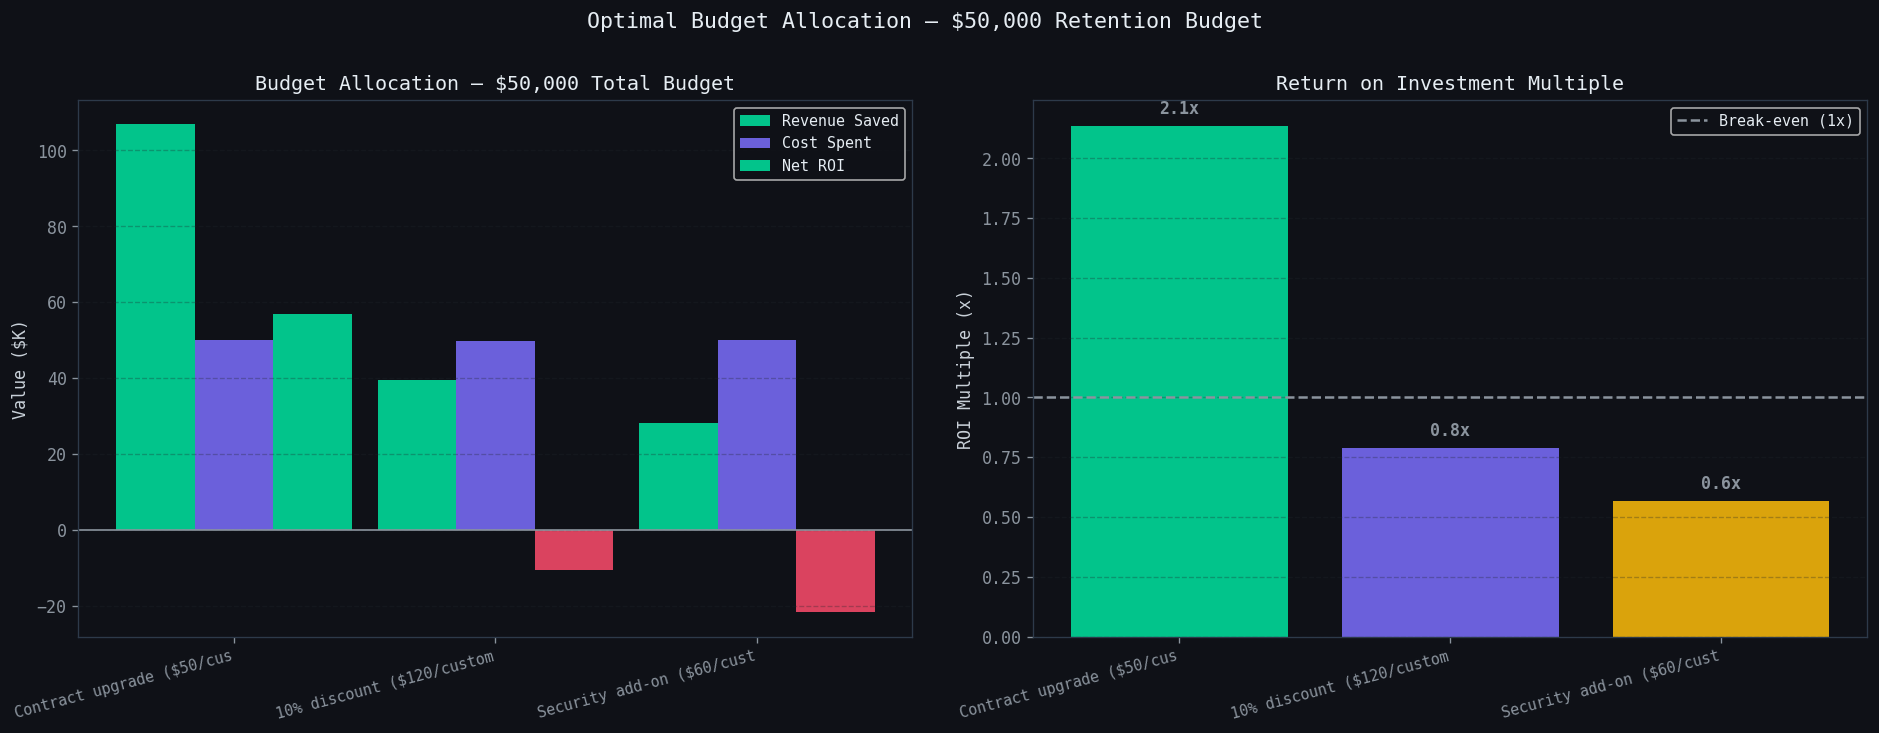


Strategy Ranking by Net ROI:
                       strategy  n_customers     rev_saved  cost       net_roi  roi_ratio
Contract upgrade ($50/customer)         1000 106857.614846 50000  56857.614846   2.137152
   10% discount ($120/customer)          416  39458.425836 49920 -10461.574164   0.790433
 Security add-on ($60/customer)          833  28311.730189 49980 -21668.269811   0.566461


In [25]:
# Given a fixed retention budget (e.g. $50,000), 
# how should we allocate it across customer segments?

TOTAL_BUDGET = 50_000  # $50K retention budget

# Cost per intervention type
COSTS = {
    "Contract upgrade ($50/customer)": 50,
    "10% discount ($120/customer)":    120,
    "Security add-on ($60/customer)":  60,
}

# Expected revenue saved per customer (from model)
X_opt   = X_test.copy()
results_opt = []

for label, cost_per in COSTS.items():
    n_affordable = int(TOTAL_BUDGET / cost_per)
    
    # Target highest-risk customers first (greedy allocation)
    sorted_idx = np.argsort(ORIG_PROB)[::-1][:n_affordable]
    mask       = np.zeros(len(X_test), dtype=bool)
    mask[sorted_idx] = True
    
    X_s = X_test.copy()
    if "Contract" in label:
        m2m_s = X_s["contract"] == "Month-to-Month"
        X_s.loc[mask & m2m_s.values, "contract"] = "One Year"
    elif "discount" in label:
        X_s.loc[mask, "monthly_charge"] *= 0.90
    elif "Security" in label:
        no_s = X_s["online_security"].isin(["No","0"])
        X_s.loc[mask & no_s.values, "online_security"] = "Yes"
    
    sim_prob  = model.predict_proba(X_s)[:, 1]
    rev_saved = ((ORIG_PROB - sim_prob).clip(0) * MONTHLY * 18).sum()
    actual_cost = mask.sum() * cost_per
    
    results_opt.append({
        "strategy":      label,
        "n_customers":   mask.sum(),
        "rev_saved":     rev_saved,
        "cost":          actual_cost,
        "net_roi":       rev_saved - actual_cost,
        "roi_ratio":     rev_saved / actual_cost if actual_cost > 0 else 0,
    })

opt_df = pd.DataFrame(results_opt).sort_values("net_roi", ascending=False)

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0f1117")

ax = axes[0]
strats = opt_df["strategy"].str[:25].tolist()
x = np.arange(len(strats)); w = 0.3
ax.bar(x - w, opt_df["rev_saved"]/1000, w, color=GREEN,  alpha=0.85, label="Revenue Saved")
ax.bar(x,     opt_df["cost"]/1000,      w, color=PURPLE, alpha=0.85, label="Cost Spent")
ax.bar(x + w, opt_df["net_roi"]/1000,   w,
       color=[GREEN if n>0 else RED for n in opt_df["net_roi"]],
       alpha=0.85, label="Net ROI")
ax.set_xticks(x); ax.set_xticklabels(strats, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Value ($K)"); ax.set_title(f"Budget Allocation — ${TOTAL_BUDGET:,} Total Budget")
ax.legend(fontsize=9); ax.grid(True, axis="y", alpha=0.3)
ax.axhline(0, color=MUTED, lw=1)

ax = axes[1]
bars = ax.bar(strats, opt_df["roi_ratio"], color=COLORS[:len(strats)], alpha=0.85)
ax.set_xticklabels(strats, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("ROI Multiple (x)"); ax.set_title("Return on Investment Multiple")
ax.axhline(1, color=MUTED, lw=1.5, linestyle="--", label="Break-even (1x)")
ax.legend(fontsize=9); ax.grid(True, axis="y", alpha=0.3)
for bar, val in zip(bars, opt_df["roi_ratio"]):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.05,
            f"{val:.1f}x", ha="center", fontsize=10, fontweight="bold", color=MUTED)

plt.suptitle(f"Optimal Budget Allocation — ${TOTAL_BUDGET:,} Retention Budget",
             fontsize=13, y=1.01, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/07_budget_allocation.png", bbox_inches="tight", facecolor="#0f1117")
plt.show()

print("\nStrategy Ranking by Net ROI:")
print(opt_df[["strategy","n_customers","rev_saved","cost","net_roi","roi_ratio"]].to_string(index=False))


## 9 · Executive Summary — Board-Ready Output

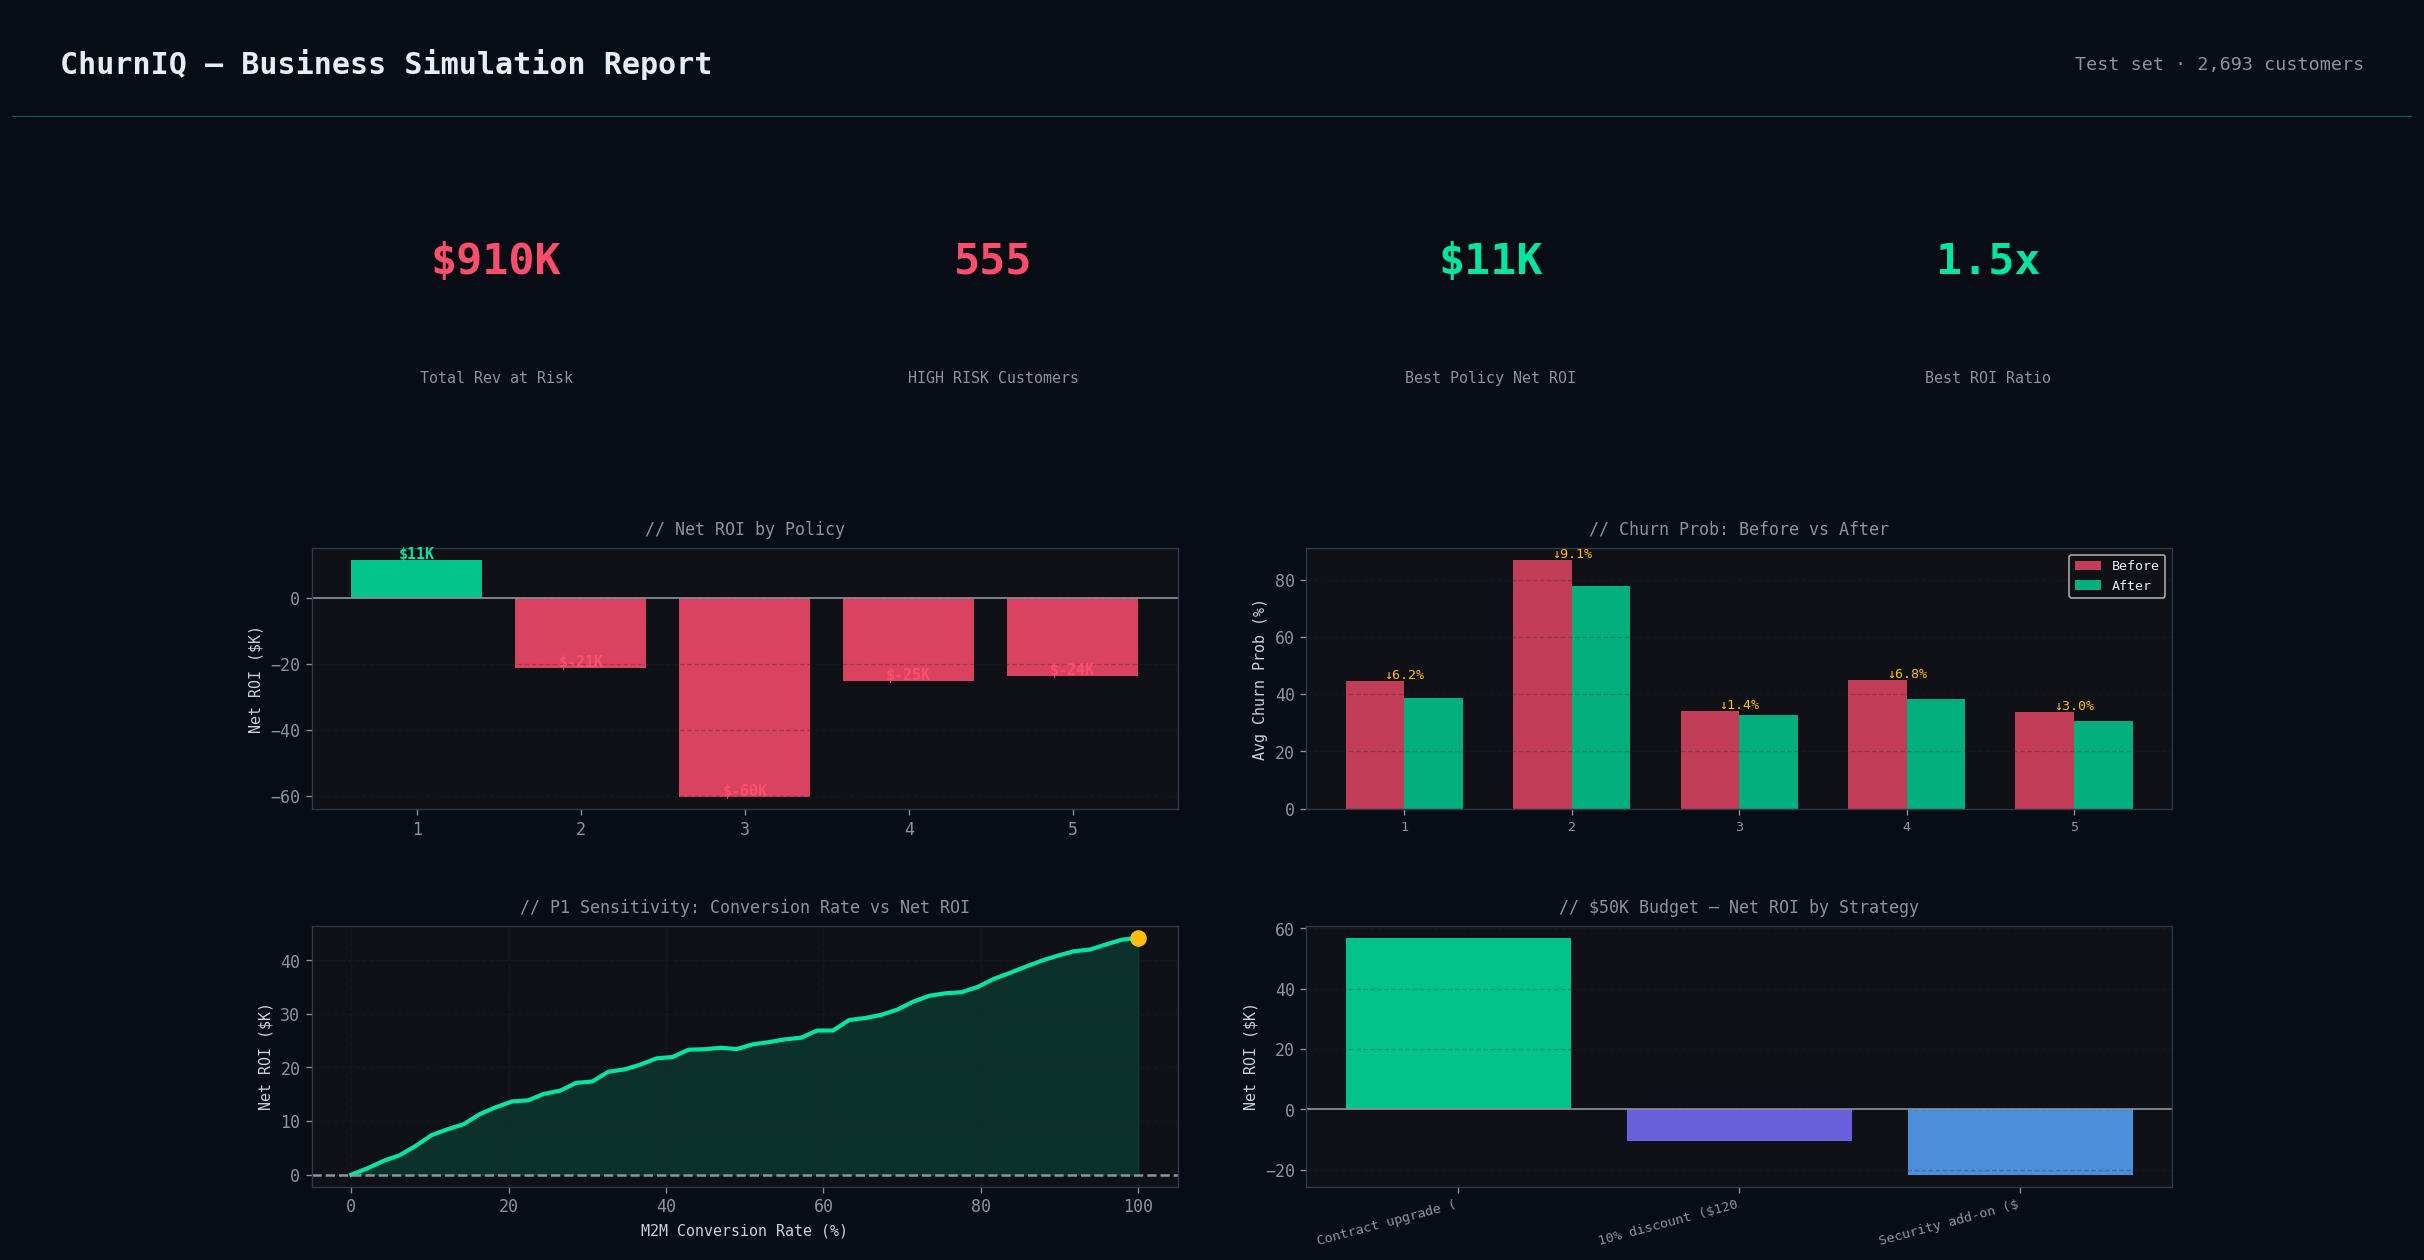

✅ Executive summary saved


In [26]:
fig = plt.figure(figsize=(20, 11))
fig.patch.set_facecolor("#080c14")
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

title_kw = dict(fontsize=10, color=MUTED, pad=8, fontfamily="monospace")
val_kw   = dict(fontsize=26, fontweight="bold", fontfamily="monospace")

# ── Header ────────────────────────────────────────────────────
ax_title = fig.add_axes([0, 0.92, 1, 0.08])
ax_title.set_facecolor("#080c14"); ax_title.axis("off")
ax_title.text(0.02, 0.5, "ChurnIQ — Business Simulation Report",
              fontsize=18, fontweight="bold", color="#e6edf3",
              va="center", fontfamily="monospace")
ax_title.text(0.98, 0.5, f"Test set · {len(X_test):,} customers",
              fontsize=11, color=MUTED, va="center", ha="right", fontfamily="monospace")
ax_title.axhline(0, color=GREEN, lw=2, alpha=0.4)

# ── KPI cards ─────────────────────────────────────────────────
kpis = [
    ("Total Rev at Risk",  f"${TOTAL_REV_RISK/1000:.0f}K",  RED),
    ("HIGH RISK Customers",f"{HIGH_RISK:,}",                 RED),
    ("Best Policy Net ROI",f"${max(p['net_roi'] for p in POLICIES)/1000:.0f}K", GREEN),
    ("Best ROI Ratio",     f"{max(p['roi_ratio'] for p in POLICIES):.1f}x",     GREEN),
]
for i, (lbl, val, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor("#111827")
    ax.axis("off")
    ax.text(0.5, 0.65, val,  ha="center", va="center", color=color, **val_kw, transform=ax.transAxes)
    ax.text(0.5, 0.2,  lbl,  ha="center", va="center", color=MUTED, fontsize=9,
            fontfamily="monospace", transform=ax.transAxes)
    for spine in ["top","bottom","left","right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(color); ax.spines[spine].set_linewidth(1.5)

# ── Policy ROI bar ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
labs  = [p["label"].replace("P","").split(":")[0].strip()[:20] for p in POLICIES]
nets  = [p["net_roi"] for p in POLICIES]
bcolors = [GREEN if n > 0 else RED for n in nets]
bars  = ax2.bar(labs, [n/1000 for n in nets], color=bcolors, alpha=0.85)
ax2.axhline(0, color=MUTED, lw=1)
ax2.set_ylabel("Net ROI ($K)", fontsize=9)
ax2.set_title("// Net ROI by Policy", **title_kw)
ax2.grid(True, axis="y", alpha=0.3)
for bar, val in zip(bars, nets):
    ax2.text(bar.get_x()+bar.get_width()/2, val/1000+(max(nets)/1000*0.03),
             f"${val/1000:.0f}K", ha="center", fontsize=9, fontweight="bold",
             color=GREEN if val>0 else RED)

# ── Probability shift ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2:])
before = [p["avg_prob_before"]*100 for p in POLICIES]
after  = [p["avg_prob_after"]*100  for p in POLICIES]
x = np.arange(len(POLICIES)); w = 0.35
ax3.bar(x-w/2, before, w, color=RED,   alpha=0.75, label="Before")
ax3.bar(x+w/2, after,  w, color=GREEN, alpha=0.75, label="After")
ax3.set_xticks(x); ax3.set_xticklabels(labs, fontsize=8)
ax3.set_ylabel("Avg Churn Prob (%)", fontsize=9)
ax3.set_title("// Churn Prob: Before vs After", **title_kw)
ax3.legend(fontsize=8); ax3.grid(True, axis="y", alpha=0.3)
for i,(b,a) in enumerate(zip(before,after)):
    if b-a > 0.5:
        ax3.text(i, max(b,a)+0.8, f"↓{b-a:.1f}%", ha="center", fontsize=8, color=AMBER)

# ── Sensitivity curve ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, :2])
ax4.plot(sens_df["rate"], sens_df["net_roi"]/1000, color=GREEN, lw=2.5)
ax4.fill_between(sens_df["rate"], sens_df["net_roi"]/1000, 0,
                 where=sens_df["net_roi"]>=0, alpha=0.15, color=GREEN)
ax4.axhline(0, color=MUTED, lw=1.5, linestyle="--")
ax4.scatter(optimal["rate"], optimal["net_roi"]/1000, color=AMBER, s=80, zorder=5)
ax4.set_xlabel("M2M Conversion Rate (%)", fontsize=9)
ax4.set_ylabel("Net ROI ($K)", fontsize=9)
ax4.set_title("// P1 Sensitivity: Conversion Rate vs Net ROI", **title_kw)
ax4.grid(True, alpha=0.3)

# ── Budget allocation ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 2:])
ax5.bar(opt_df["strategy"].str[:18], opt_df["net_roi"]/1000,
        color=[GREEN,PURPLE,BLUE][:len(opt_df)], alpha=0.85)
ax5.set_ylabel("Net ROI ($K)", fontsize=9)
ax5.set_title(f"// $50K Budget — Net ROI by Strategy", **title_kw)
ax5.set_xticklabels(opt_df["strategy"].str[:18], rotation=15, ha="right", fontsize=8)
ax5.axhline(0, color=MUTED, lw=1); ax5.grid(True, axis="y", alpha=0.3)

plt.savefig("../outputs/07_executive_summary.png",
            bbox_inches="tight", facecolor="#080c14", dpi=150)
plt.show()
print("✅ Executive summary saved")


## Summary

In [27]:
print("=" * 60)
print("  07 WHAT-IF SIMULATOR — COMPLETE")
print("=" * 60)

print("\nPolicy Results (test set):")
for p in POLICIES:
    status = "✅ PROFITABLE" if p["net_roi"] > 0 else "❌ NOT PROFITABLE"
    print(f"  {p['label']:<35} ${p['net_roi']:>9,.0f}  {status}")

print(f"\n  Best policy: {max(POLICIES, key=lambda p: p['net_roi'])['label']}")
print(f"  Max net ROI: ${max(p['net_roi'] for p in POLICIES):,.0f}")
print(f"  Break-even conversion rate: {break_even:.1f}%")

outputs = ["07_baseline_dashboard.png","07_policy_comparison.png",
           "07_sensitivity_analysis.png","07_budget_allocation.png",
           "07_executive_summary.png"]
print("\nSaved charts:")
for f in outputs:
    exists = os.path.exists(f"../outputs/{f}")
    print(f"  {'✅' if exists else '⬜'} {f}")


  07 WHAT-IF SIMULATOR — COMPLETE

Policy Results (test set):
  P1: 30% M2M → One Year              $   11,435  ✅ PROFITABLE
  P2: $10 Discount → HIGH RISK        $  -21,191  ❌ NOT PROFITABLE
  P3: Free Security Add-on            $  -60,200  ❌ NOT PROFITABLE
  P4: ALL M2M → One Year              $  -25,055  ❌ NOT PROFITABLE
  P5: M2M Upgrade + Security          $  -23,673  ❌ NOT PROFITABLE

  Best policy: P1: 30% M2M → One Year
  Max net ROI: $11,435
  Break-even conversion rate: 0.0%

Saved charts:
  ✅ 07_baseline_dashboard.png
  ✅ 07_policy_comparison.png
  ✅ 07_sensitivity_analysis.png
  ✅ 07_budget_allocation.png
  ✅ 07_executive_summary.png
